In [ ]:
# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [ ]:
# =============================================================================
# 2. LOAD DATA AND INITIAL ANALYSIS
# =============================================================================
# Load the data from the .data file
df = pd.read_csv('transfusion.data')

# Assign the correct column names
columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Don']
df.columns = columns

print("--- 1. Initial Data Analysis ---")
print(f"\n--- Shape of the Dataset (Size):{df.shape}")

print("\n--- Data Types and Non-Null Counts (Info) ---")
df.info()

print("\n--- Statistical Summary ---")
print(df.describe())



--- 1. Initial Data Analysis ---

--- Shape of the Dataset (Size):(748, 5)

--- Data Types and Non-Null Counts (Info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Don        748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB

--- Statistical Summary ---
          Recency   Frequency      Monetary        Time         Don
count  748.000000  748.000000    748.000000  748.000000  748.000000
mean     9.506684    5.514706   1378.676471   34.282086    0.237968
std      8.095396    5.839307   1459.826781   24.376714    0.426124
min      0.000000    1.000000    250.000000    2.000000    0.000000
25%      2.750000    2.000000    500.000000   16.000000    0.000000
50%      7.000000    4.000000   

In [ ]:
# =============================================================================
# 3. HANDLE NULL VALUES AND DUPLICATES
# =============================================================================
print("\n--- 2. Handling Null Values and Duplicates ---")

print("\n--- Checking for Null Values ---")
print(df.isnull().sum())
# No action needed as this dataset has no nulls, but this is the standard check.

print(f"\nNumber of duplicate rows before cleaning: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after cleaning duplicates: {len(df)}")



--- 2. Handling Null Values and Duplicates ---

--- Checking for Null Values ---
Recency      0
Frequency    0
Monetary     0
Time         0
Don          0
dtype: int64

Number of duplicate rows before cleaning: 215
Number of rows after cleaning duplicates: 533



--- 3. 'Before' Visualization (EDA on Original Data) ---


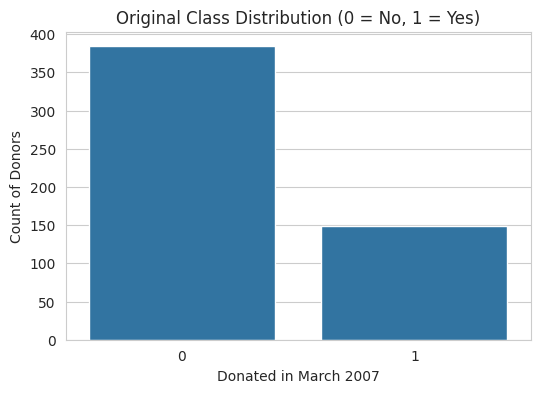

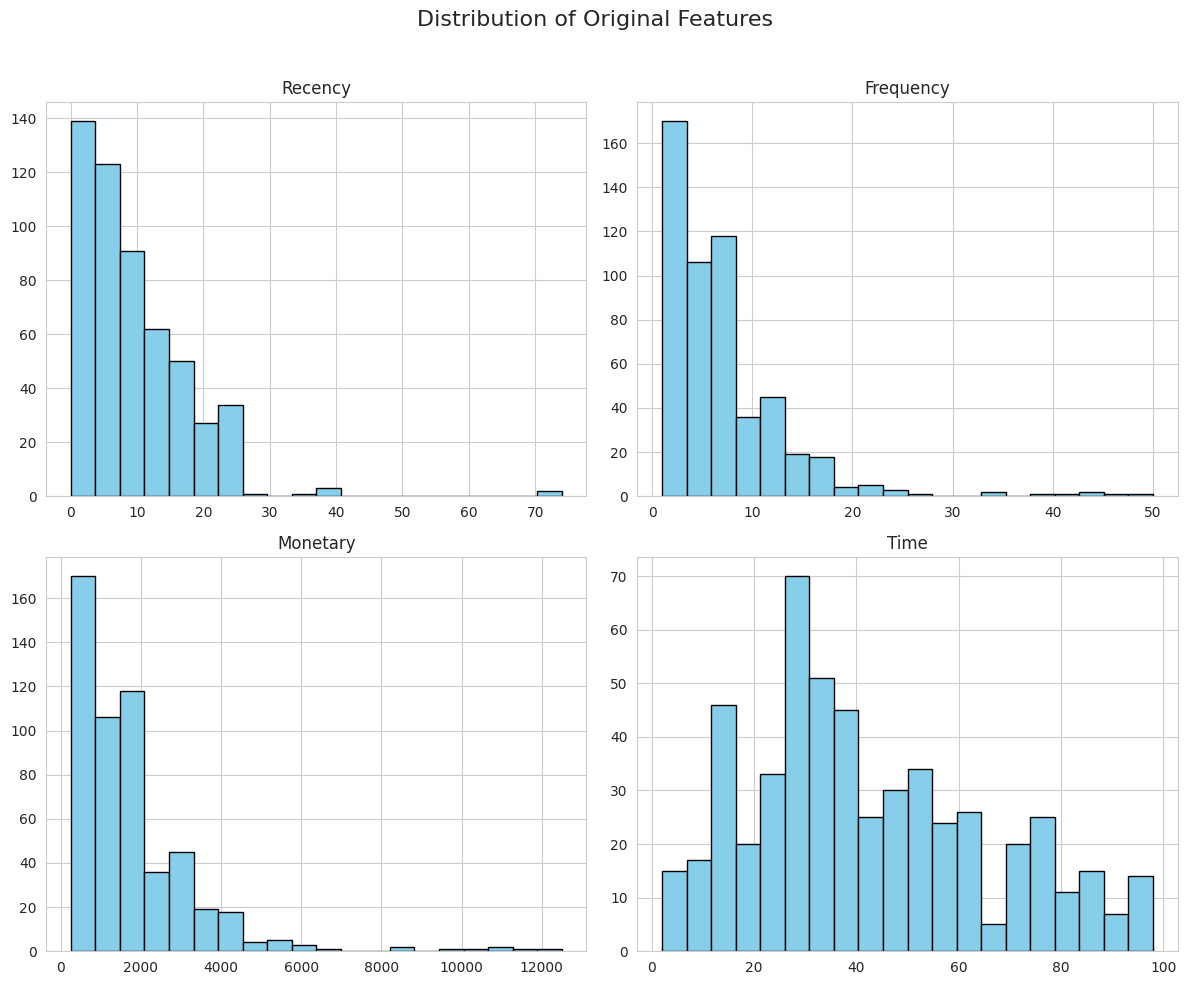


--- Generating Individual Box Plots for Each Feature ---


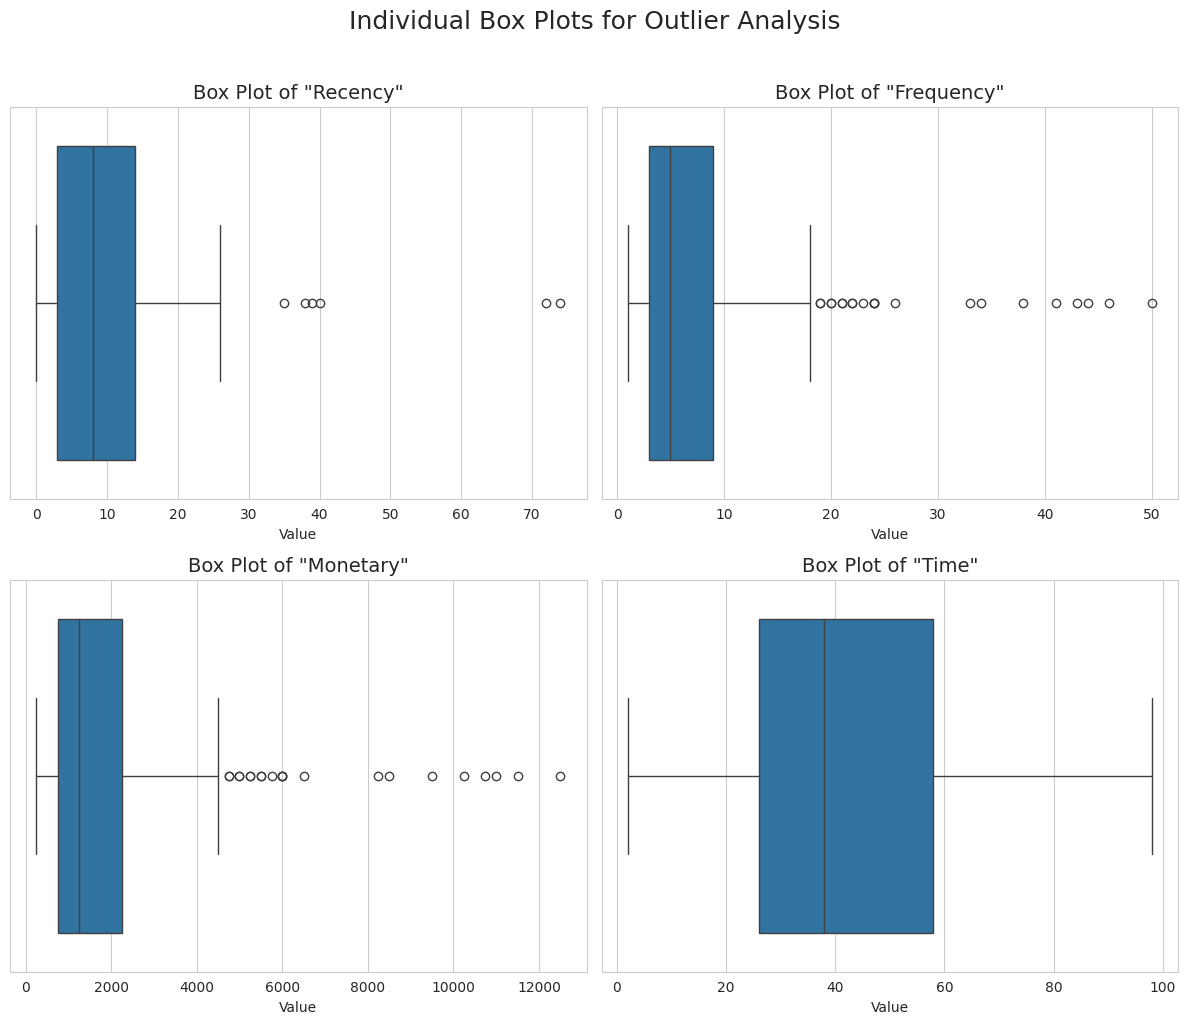

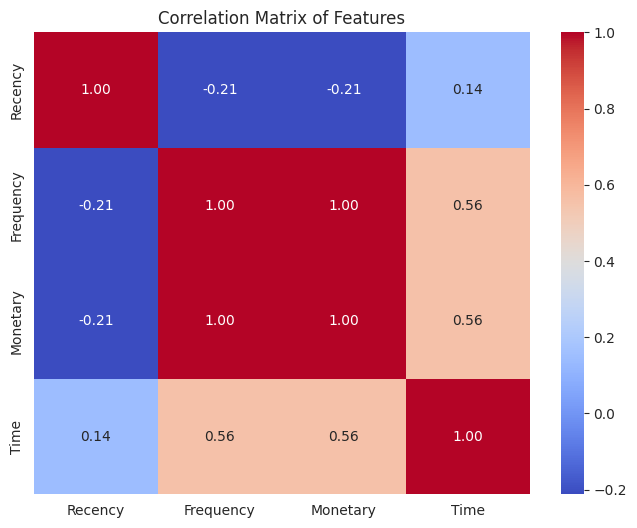

In [ ]:
# =============================================================================
# 4. "BEFORE" VISUALIZATION (EXPLORATORY DATA ANALYSIS)
# =============================================================================
print("\n--- 3. 'Before' Visualization (EDA on Original Data) ---")
# Set a nice visual style for the plots
sns.set_style("whitegrid")

# --- a) Class Distribution (Count Plot) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Don', data=df)
plt.title('Original Class Distribution (0 = No, 1 = Yes)')
plt.xlabel('Donated in March 2007')
plt.ylabel('Count of Donors')
plt.show()

# --- b) Feature Distributions (Histograms) ---
features_for_viz = df.drop('Don', axis=1)
features_for_viz.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Original Features', size=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- c) Outlier Analysis (Individual Box Plots) ---
# List of features to plot
features = ['Recency', 'Frequency', 'Monetary', 'Time']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

print("\n--- Generating Individual Box Plots for Each Feature ---")

# Loop through each feature and create a box plot on a separate subplot
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f'Box Plot of "{feature}"', fontsize=14)
    axes[i].set_xlabel('Value')

# Add a main title and adjust layout
plt.suptitle('Individual Box Plots for Outlier Analysis', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# --- d) Correlation Matrix (Heatmap) ---
plt.figure(figsize=(8, 6))
sns.heatmap(features_for_viz.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


In [ ]:
# =============================================================================
# 5. DATA PREPROCESSING
# =============================================================================
print("\n--- 4. Data Preprocessing ---")

# --- a) Separate Features (X) and Target (y) ---
X = df.drop('Don', axis=1)
y = df['Don']

# --- b) Split into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Original training set size: {len(X_train)} rows.")

# --- c) Remove Outliers from the Training Set (using IQR) ---
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

# Define the outlier detection boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = ((X_train < lower_bound) | (X_train > upper_bound)).any(axis=1)

# Remove the outliers from the training set
X_train_clean = X_train[~outliers]
y_train_clean = y_train[~outliers]

print(f"Removed {outliers.sum()} rows identified as outliers.")
print(f"Cleaned training set size: {len(X_train_clean)} rows.")

# --- d) Handle Class Imbalance on the Cleaned Training Set ---
smote = SMOTE(random_state=42)
# Apply SMOTE to the cleaned data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_clean, y_train_clean)
print("SMOTE applied to the cleaned training set to balance classes.")

# --- e) Scale the Features ---
scaler = StandardScaler()
# Fit and transform on the cleaned, resampled training data
X_train_scaled = scaler.fit_transform(X_train_resampled)
# Only transform the original test data
X_test_scaled = scaler.transform(X_test)
print("Features scaled using StandardScaler.")


--- 4. Data Preprocessing ---
Original training set size: 426 rows.
Removed 18 rows identified as outliers.
Cleaned training set size: 408 rows.
SMOTE applied to the cleaned training set to balance classes.
Features scaled using StandardScaler.



--- Visualizing Training Data After Resampling (Before Scaling) ---


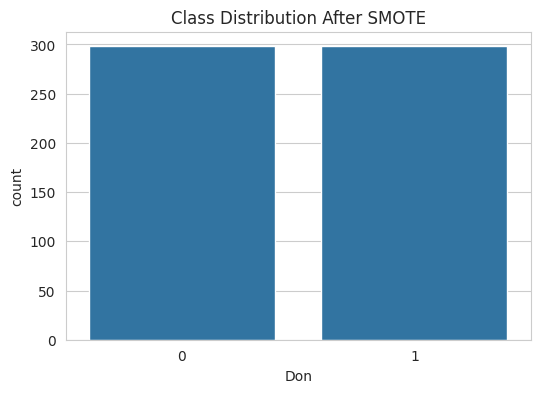


--- Box Plots After Resampling but Before Scaling ---


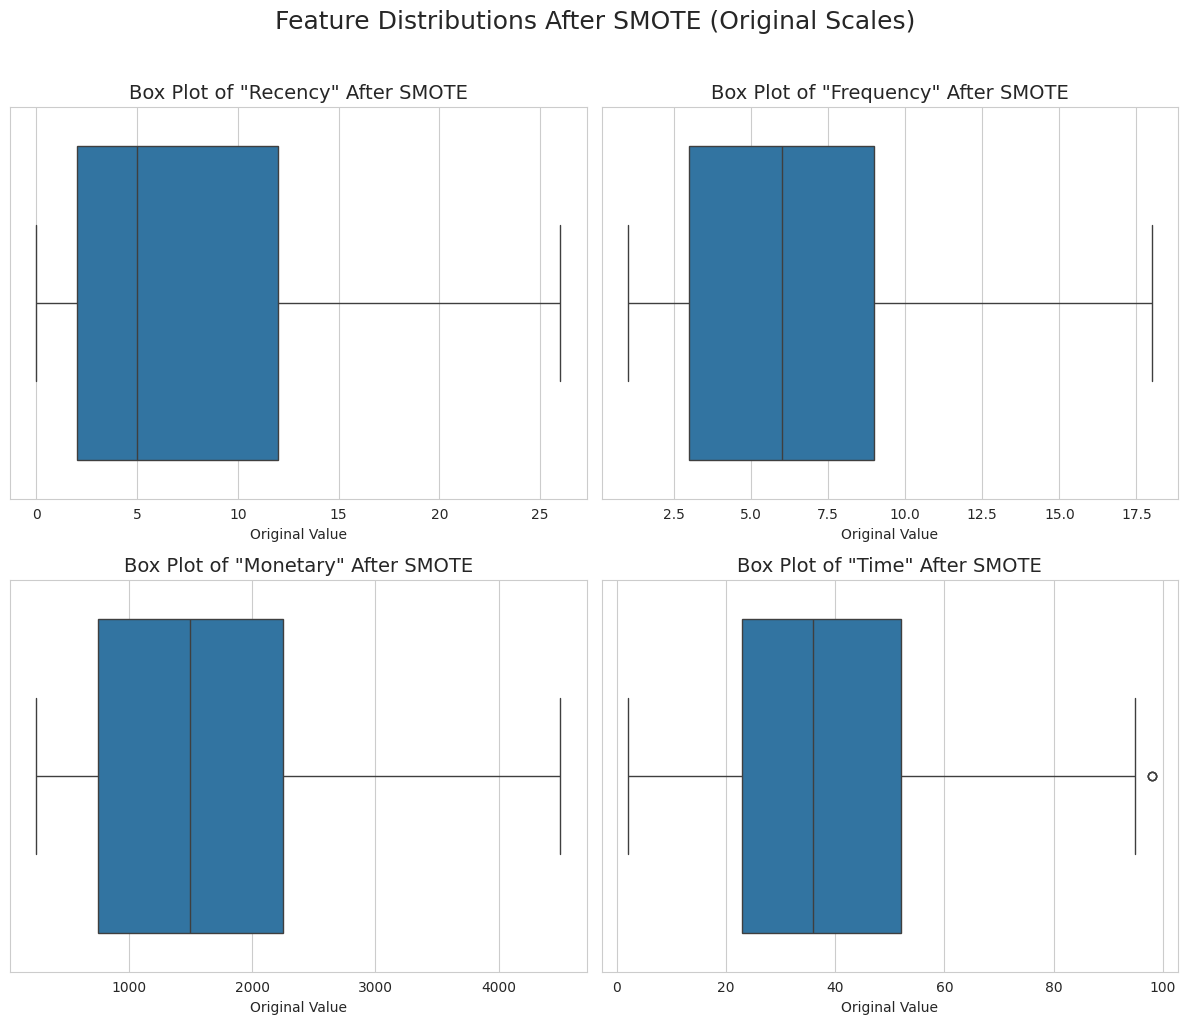

In [ ]:
# =============================================================================
# 5.5 INTERMEDIATE VISUALIZATION (After SMOTE, Before Scaling)
# =============================================================================

print("\n--- Visualizing Training Data After Resampling (Before Scaling) ---")

# Convert the resampled numpy array back to a DataFrame for easy plotting
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X.columns)

# --- a) Class Balance (already verified, but good to see again) ---
y_train_resampled_series = pd.Series(y_train_resampled, name='Don')
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled_series)
plt.title('Class Distribution After SMOTE')
plt.show()


# --- b) Individual Box Plots After SMOTE ---
# This shows the distributions on their original scale
features = ['Recency', 'Frequency', 'Monetary', 'Time']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print("\n--- Box Plots After Resampling but Before Scaling ---")

for i, feature in enumerate(features):
    sns.boxplot(x=X_train_resampled_df[feature], ax=axes[i])
    axes[i].set_title(f'Box Plot of "{feature}" After SMOTE', fontsize=14)
    axes[i].set_xlabel('Original Value')

plt.suptitle('Feature Distributions After SMOTE (Original Scales)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()


--- 5. 'After' Visualization (Verification) ---


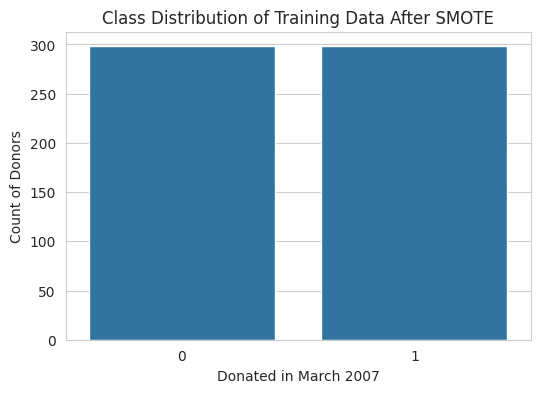


--- Generating Individual Box Plots for Each Scaled Feature ---


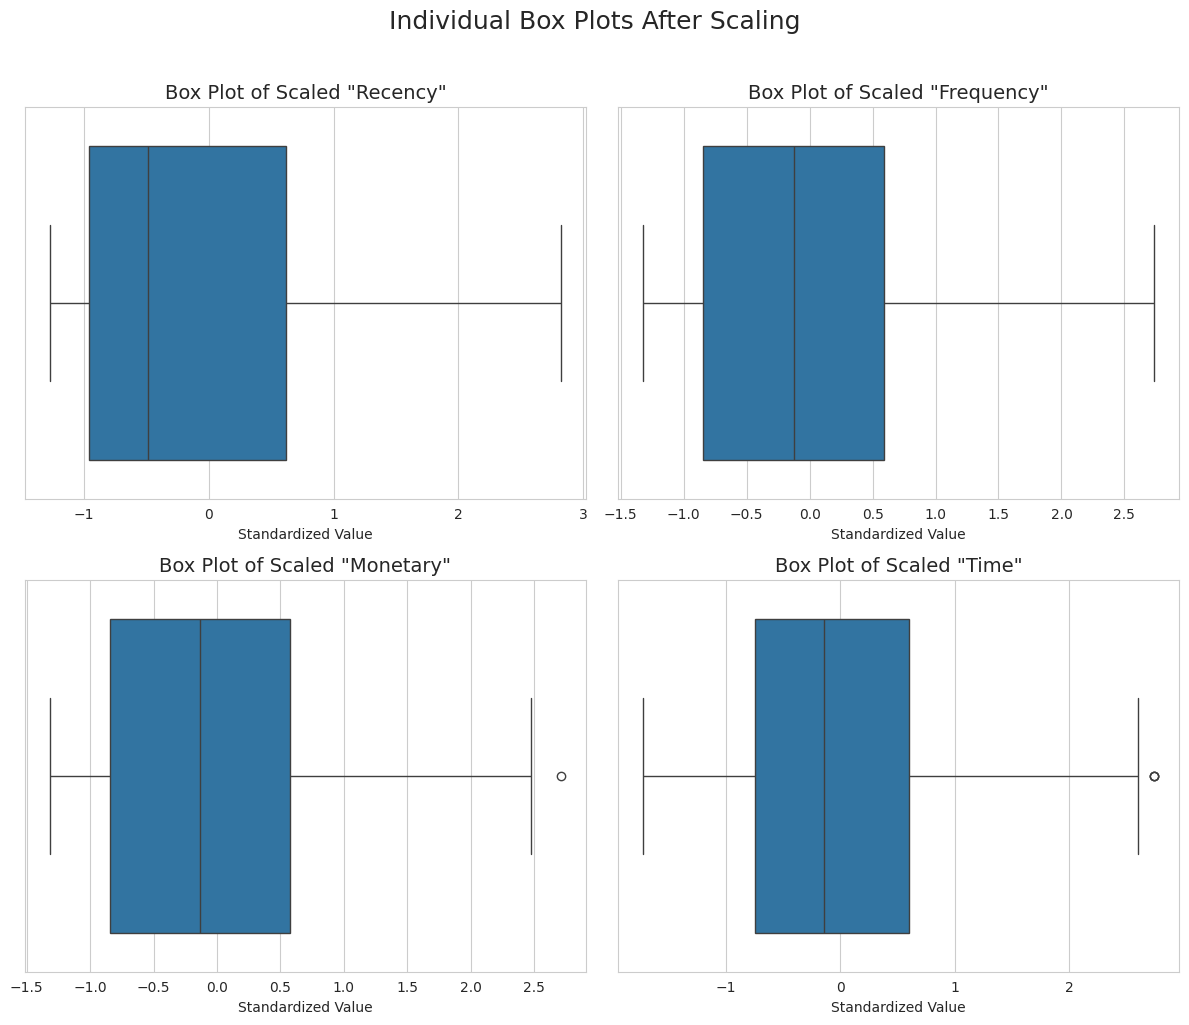


--- Workflow Complete. Data is ready for modeling. ---


In [ ]:
# =============================================================================
# 6. "AFTER" VISUALIZATION (VERIFICATION)
# =============================================================================
print("\n--- 5. 'After' Visualization (Verification) ---")

# --- a) Verify Class Balance After SMOTE ---
# Note: We create a temporary Series for plotting
y_train_resampled_series = pd.Series(y_train_resampled, name='Don')
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled_series)
plt.title('Class Distribution of Training Data After SMOTE')
plt.xlabel('Donated in March 2007')
plt.ylabel('Count of Donors')
plt.show()

# --- b) Verify Feature Scaling with Individual Box Plots ---
# We convert the scaled numpy array back to a DataFrame for easy plotting
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# List of features to plot
features = ['Recency', 'Frequency', 'Monetary', 'Time']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

print("\n--- Generating Individual Box Plots for Each Scaled Feature ---")

# Loop through each feature and create a box plot on a separate subplot
for i, feature in enumerate(features):
    sns.boxplot(x=X_train_scaled_df[feature], ax=axes[i])
    axes[i].set_title(f'Box Plot of Scaled "{feature}"', fontsize=14)
    axes[i].set_xlabel('Standardized Value')

# Add a main title and adjust layout
plt.suptitle('Individual Box Plots After Scaling', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Workflow Complete. Data is ready for modeling. ---")


--- Decision Tree with SMOTE ---
Accuracy: 0.6262
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.65      0.72        80
           1       0.35      0.56      0.43        27

    accuracy                           0.63       107
   macro avg       0.58      0.60      0.58       107
weighted avg       0.70      0.63      0.65       107



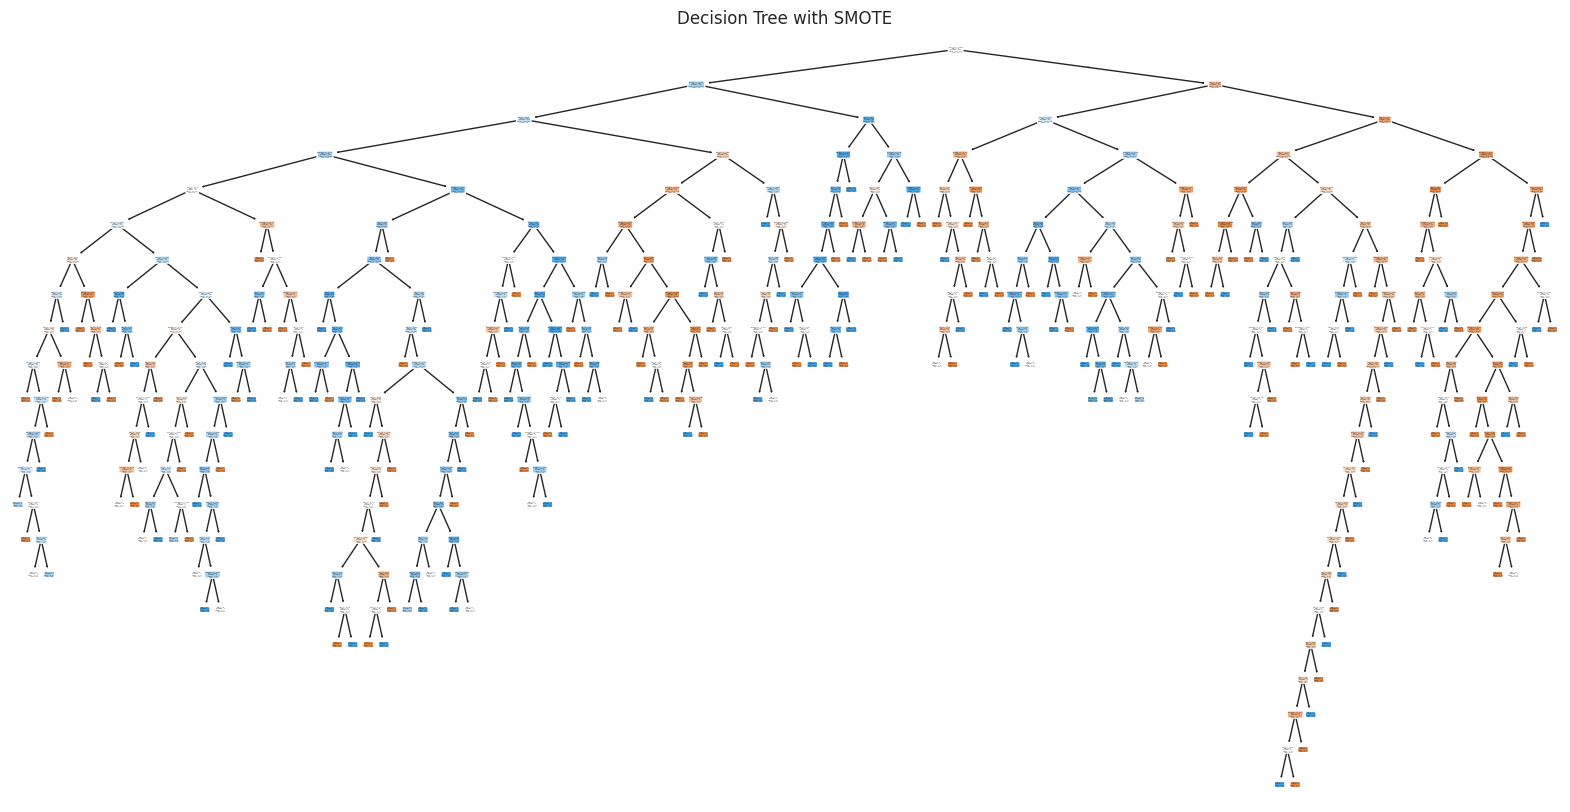

In [ ]:
# =============================================================================
# 5. DECISION TREE WITH SMOTE (Handle Imbalance)
# =============================================================================
print("\n--- Decision Tree with SMOTE ---")

# Features and target
X = df.drop('Don', axis=1)
y = df['Don']

# Train-test split (before SMOTE, to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Scale features (optional for DT, but consistent with notebook)
scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree (CART with Gini)
clf_sm = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_sm.fit(X_train_sm, y_train_sm)

# Predict and evaluate
y_pred_sm = clf_sm.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_sm):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(clf_sm, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title('Decision Tree with SMOTE')
plt.show()


--- Decision Tree Without SMOTE ---
Accuracy: 0.6822
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.81      0.79        80
           1       0.35      0.30      0.32        27

    accuracy                           0.68       107
   macro avg       0.56      0.55      0.56       107
weighted avg       0.67      0.68      0.67       107



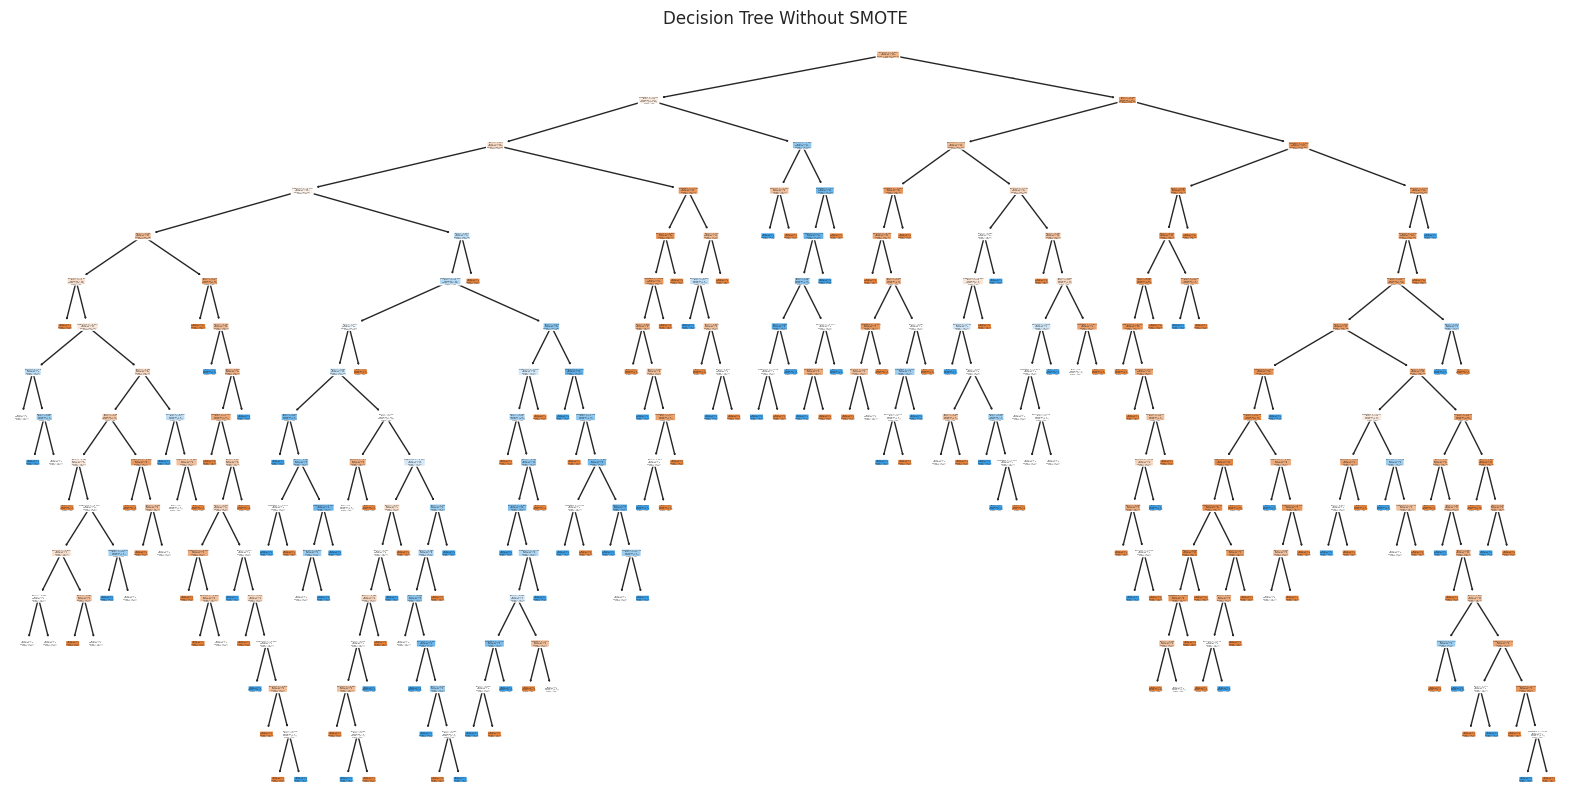

In [ ]:
# =============================================================================
# 6. DECISION TREE WITHOUT SMOTE (Direct)
# =============================================================================
print("\n--- Decision Tree Without SMOTE ---")

# Features and target
X = df.drop('Don', axis=1)
y = df['Don']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (optional)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree (CART with Gini)
clf_direct = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_direct.fit(X_train, y_train)

# Predict and evaluate
y_pred_direct = clf_direct.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_direct):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_direct))

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(clf_direct, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title('Decision Tree Without SMOTE')
plt.show()


--- Decision Tree with Stratified Split ---
Accuracy: 0.6355
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.75      0.75        77
           1       0.34      0.33      0.34        30

    accuracy                           0.64       107
   macro avg       0.54      0.54      0.54       107
weighted avg       0.63      0.64      0.63       107



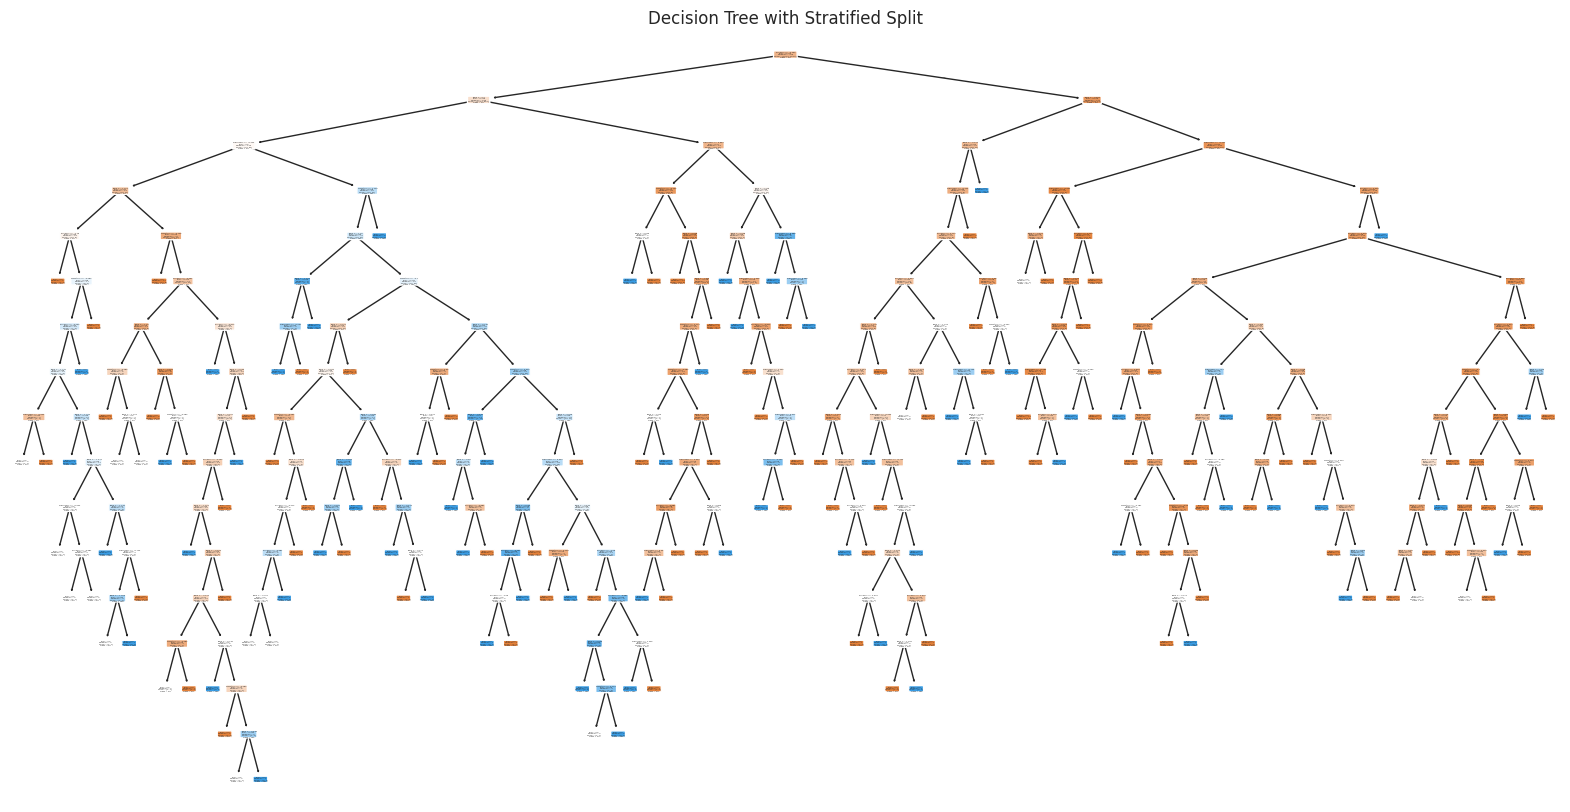

In [ ]:
# =============================================================================
# 7. DECISION TREE WITH STRATIFIED SPLIT
# =============================================================================
print("\n--- Decision Tree with Stratified Split ---")

# Features and target
X = df.drop('Don', axis=1)
y = df['Don']

# Stratified train-test split (preserves class ratios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features (optional)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Decision Tree (CART with Gini)
clf_strat = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_strat.fit(X_train, y_train)

# Predict and evaluate
y_pred_strat = clf_strat.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_strat):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_strat))

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(clf_strat, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title('Decision Tree with Stratified Split')
plt.show()


--- Decision Tree with Stratified Split and Grid Search CV ---
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation score: 0.6849
Test set accuracy: 0.7290
Classification Report:
               precision    recall  f1-score   support

           0       0.73      1.00      0.84        77
           1       1.00      0.03      0.06        30

    accuracy                           0.73       107
   macro avg       0.86      0.52      0.45       107
weighted avg       0.80      0.73      0.62       107



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


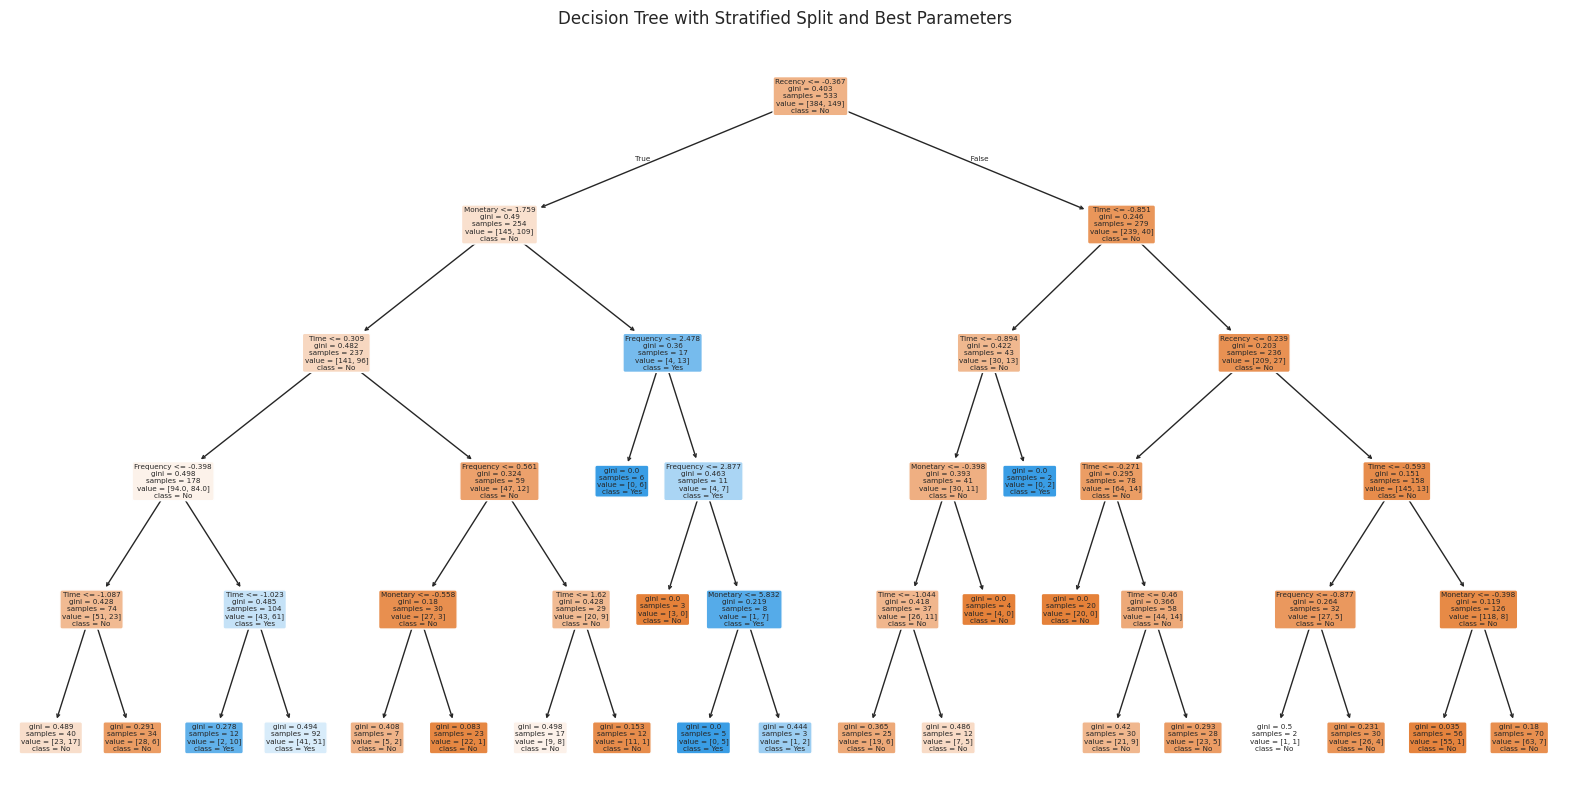

In [ ]:
# =============================================================================
# 7. DECISION TREE WITH STRATIFIED SPLIT AND GRID SEARCH CV
# =============================================================================
print("\n--- Decision Tree with Stratified Split and Grid Search CV ---")

# Features and target
X = df.drop('Don', axis=1)
y = df['Don']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define parameter grid for Grid Search CV
param_grid = {
    'max_depth': [3, 5, 7, None],  # Control tree depth to prevent overfitting
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples in leaf nodes
}

# Initialize Decision Tree
clf = DecisionTreeClassifier(criterion='gini', random_state=42)

# Perform Grid Search with 5-fold CV
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_scaled, y)

# Print results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_clf = grid_search.best_estimator_

# (Optional) If you want to evaluate on a separate test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_test_scaled = scaler.transform(X_test)  # Reapply scaling to test set
y_pred_strat = best_clf.predict(X_test_scaled)

# Predict and evaluate on test set
print(f"Test set accuracy: {accuracy_score(y_test, y_pred_strat):.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_strat))

# Visualize the tree with best parameters
plt.figure(figsize=(20, 10))
plot_tree(best_clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True)
plt.title('Decision Tree with Stratified Split and Best Parameters')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV